# LLR Photometric Redshift & Galactic Physics Pipeline

這個 Notebook 實作了利用局部線性迴歸 (Local Linear Regression, LLR) 從光學波段測光資料推算測光紅移 ($z_{phot}$) 的流程（類似於 SDSS DR12 所採用的方法），並進而推算宇宙學距離與絕對物理量。

### Step 1: Data Ingestion & Parameter Setup
在此步驟中我們載入訓練集 (`train_data.csv`) 與目標集 (`target_data.csv`)。為確保流程能獨立測試，若找不到檔案，將自動生成模擬的星系資料供後續使用。

In [3]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import matplotlib.pyplot as plt

%matplotlib inline

# 載入資料集
try:
    df = pd.read_csv('../data/training/training_data.csv')
    train_df = df[:int(len(df)*0.7)]
    target_df = df[int(len(df)*0.7):]
    print("成功載入 train_data.csv 與 target_data.csv！")
except FileNotFoundError:
    print("找不到資料集檔案，將自動生成模擬的訓練集與測試集供測試...")
    np.random.seed(42)
    
    def generate_mock_data(n, is_train=False):
        data = {
            'objID': np.arange(n),
            'RA': np.random.uniform(150, 200, n),
            'Dec': np.random.uniform(-5, 5, n),
            'cModelMag_u': np.random.normal(22, 1, n),
            'cModelMag_g': np.random.normal(21, 1, n),
            'cModelMag_r': np.random.normal(20, 1, n),
            'cModelMag_i': np.random.normal(19.5, 1, n),
            'cModelMag_z': np.random.normal(19, 1, n),
            'extinction_u': np.random.uniform(0.05, 0.2, n),
            'extinction_g': np.random.uniform(0.04, 0.15, n),
            'extinction_r': np.random.uniform(0.03, 0.1, n),
            'extinction_i': np.random.uniform(0.02, 0.08, n),
            'extinction_z': np.random.uniform(0.01, 0.05, n),
        }
        if is_train:
            # 訓練集包含精確的光譜紅移 (z_spec)
            # 模擬：紅移大致上與 r 波段星等與隨機雜訊相關
            data['z_spec'] = np.clip((data['cModelMag_r'] - 15) * 0.1 + np.random.normal(0, 0.05, n), 0.01, 1.0)
        return pd.DataFrame(data)

    # 生成 5000 筆訓練資料與 1000 筆測試資料
    train_df = generate_mock_data(5000, is_train=True)
    target_df = generate_mock_data(1000, is_train=False)

成功載入 train_data.csv 與 target_data.csv！


### Step 2: Photometric Dereddening & Feature Engineering
在此我們進行「去紅化」處理 (`mag_dered = cModelMag - extinction`)，並構建機器學習所需的 5 維度特徵空間：一個去紅化 $r$ 波段星等以及四個顏色指數 ($u-g$, $g-r$, $r-i$, $i-z$)。最後使用 `StandardScaler` 將特徵標準化。

In [4]:
def extract_features(df):
    """
    計算去紅化星等並提取 5 維度的特徵空間。
    """
    df = df.copy()
    bands = ['u', 'g', 'r', 'i', 'z']
    
    # 1. 去紅化計算
    for b in bands:
        if f'cModelMag_{b}' in df.columns and f'extinction_{b}' in df.columns:
            df[f'dered_{b}'] = df[f'cModelMag_{b}'] - df[f'extinction_{b}']
        else:
            raise ValueError(f"缺少 {b} 波段的資料")
            
    # 2. 計算 5D 測光特徵空間
    features = pd.DataFrame()
    features['mag_r'] = df['dered_r']
    features['u-g'] = df['dered_u'] - df['dered_g']
    features['g-r'] = df['dered_g'] - df['dered_r']
    features['r-i'] = df['dered_r'] - df['dered_i']
    features['i-z'] = df['dered_i'] - df['dered_z']
    
    return df, features
#上面出問題


# 提取特徵
train_df, train_features = extract_features(train_df)
target_df, target_features = extract_features(target_df)

# 3. 使用 StandardScaler 進行標準化 
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
target_features_scaled = scaler.transform(target_features)

print("特徵工程與標準化完成！")

特徵工程與標準化完成！


### Step 3: The DR12 Local Linear Regression (LLR) Algorithm
利用最近鄰 (`NearestNeighbors`) 在訓練集中為每個目標星系尋找 $k=100$ 個最近的鄰居，接著對這 100 個鄰居套用局部線性迴歸 (`LinearRegression`) 並利用 $3\sigma$ 剔除異常值，最後預測出 $z_{phot}$ 及推估其誤差。

In [5]:
def calculate_photometric_redshift_llr(train_features, train_z_spec, target_features, k=100):
    """
    實作包含 Outlier Rejection 的局部線性迴歸演算法 (LLR)。
    """
    # 1. 初始化 NearestNeighbors
    nn = NearestNeighbors(n_neighbors=k, algorithm='auto')
    nn.fit(train_features)
    
    z_phot_pred = np.zeros(len(target_features))
    z_phot_err = np.zeros(len(target_features))
    
    # 2. 針對「每一個」目標星系進行預測
    for i, target_feat in enumerate(target_features):
        # 尋找 k=100 個最近鄰
        distances, indices = nn.kneighbors([target_feat])
        neighbor_idx = indices[0]
        
        # 3. 提取特徵與真實紅移
        X_neighbors = train_features[neighbor_idx]
        y_neighbors = train_z_spec.iloc[neighbor_idx].values
        
        # 4. 首次擬合局部超平面
        lr = LinearRegression()
        lr.fit(X_neighbors, y_neighbors)
        
        # 5. Outlier Rejection Loop (剔除 > 3 sigma 殘差的鄰居)
        predictions = lr.predict(X_neighbors)
        residuals = np.abs(y_neighbors - predictions)
        std_residual = np.std(residuals)
        valid_mask = residuals < (3 * std_residual)
        
        # 防呆：如果剔除後鄰居過少，則不進行剔除
        if np.sum(valid_mask) > 10:
            X_clean, y_clean = X_neighbors[valid_mask], y_neighbors[valid_mask]
        else:
            X_clean, y_clean = X_neighbors, y_neighbors
            
        # 6. 利用剩下的鄰居重新擬合 (Re-fit)
        lr.fit(X_clean, y_clean)
        
        # 7. 預測目標星系的 z_phot (確保紅移不會小於0)
        z_pred = max(lr.predict([target_feat])[0], 0.0)
        z_phot_pred[i] = z_pred
        
        # 8. 儲存局部標準差作為誤差估計
        final_residuals = y_clean - lr.predict(X_clean)
        z_phot_err[i] = np.std(final_residuals)
        
    return z_phot_pred, z_phot_err

print("開始進行 LLR 測光紅移推算... (若資料量大可能需時數秒至數分鐘)")
target_df['z_phot'], target_df['z_phot_err'] = calculate_photometric_redshift_llr(
    train_features_scaled, 
    train_df['spec_redshift'], 
    target_features_scaled, 
    k=100
)
print("LLR 測光紅移計算完成！")

開始進行 LLR 測光紅移推算... (若資料量大可能需時數秒至數分鐘)
LLR 測光紅移計算完成！


### Step 4: Cosmological Physical Parameters
初始化 `FlatLambdaCDM` 宇宙學模型，將上一步獲得的預測紅移轉換為發光距離 (Mpc 轉 pc)。再利用距離模數公式計算絕對星等 ($M_r$) 及通量。*(註：為簡化 baseline，此處假設 K-correction = 0)*

In [6]:
# 初始化 Flat Lambda-CDM 宇宙學模型
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

def calculate_physical_parameters(df):
    # 避免紅移為 0 導致發光距離與對數運算錯誤，設定下限
    z_safe = np.clip(df['z_phot'].values, 1e-4, None)
    
    # 1. 計算發光距離 D_L (單位 Mpc) 並轉換為 pc
    df['D_L_Mpc'] = cosmo.luminosity_distance(z_safe).value
    df['D_L_pc'] = df['D_L_Mpc'] * 1e6
    
    # 2. 計算絕對星等 (Absolute Magnitude)
    # 公式: M_r = m_r - 5*log10(D_L/10) - K_correction
    # 備註: 這裡暫時假設 K-correction = 0
    distance_modulus = 5 * np.log10(df['D_L_pc'] / 10)
    df['Absolute_Mag_r'] = df['dered_r'] - distance_modulus
    
    # 3. 計算相對通量 (Flux)
    # 基於標準 SDSS AB 零點系統轉換: Flux = 10 ** ((8.90 - m) / 2.5)
    df['Calculated_Flux'] = 10 ** ((8.90 - df['dered_r']) / 2.5)
    
    return df

target_df = calculate_physical_parameters(target_df)
print("物理參數計算完成！")

物理參數計算完成！


### Step 5: Data Export
將最終求出的特性欄位合併，存出為一個乾淨的 DataFrame 並輸出成 `.csv` 檔。

In [7]:
export_columns = [
    'objid', 'ra', 'dec', 'z_phot', 'z_phot_err', 
    'D_L_Mpc', 'Absolute_Mag_r', 'Calculated_Flux'
]

final_catalog = target_df[export_columns].copy()

# 匯出至 CSV
output_filename = 'calculated_photometric_catalog.csv'
final_catalog.to_csv(output_filename, index=False)
print(f"最終星表已經成功匯出至 {output_filename}！")
display(final_catalog.head())

最終星表已經成功匯出至 calculated_photometric_catalog.csv！


,objid,ra,dec,z_phot,z_phot_err,D_L_Mpc,Absolute_Mag_r,Calculated_Flux
254346,1237679034014695492,352.787452,8.932442,0.262802,0.022106,1333.923048,-22.723780,0.000251
254347,1237663783675888024,35.129730,-0.398383,0.232455,0.067450,1160.429718,-21.246500,0.000085
254348,1237669518509212045,345.266017,7.680888,0.322001,0.031856,1685.185609,-22.815446,0.000171
254349,1237663783139213446,35.549848,-0.642917,0.084435,0.014075,384.572095,-21.519201,0.000995
254350,1237678905175310937,7.854777,8.859935,0.568420,0.068893,3306.329752,-22.532852,0.000034


### Step 6: Visualizations (Sanity Checks)
藉由視覺化以防呆與確認物理性質分布。
1. 左圖：星系在天球的二維分布，並利用我們推算的 $z_{phot}$ 著色。
2. 右圖：顏色-星等圖 (CMD, $M_r$ vs $g-r$)，用以確認是否能看到星系的紅序 (Red Sequence) 與藍雲 (Blue Cloud) 分布。

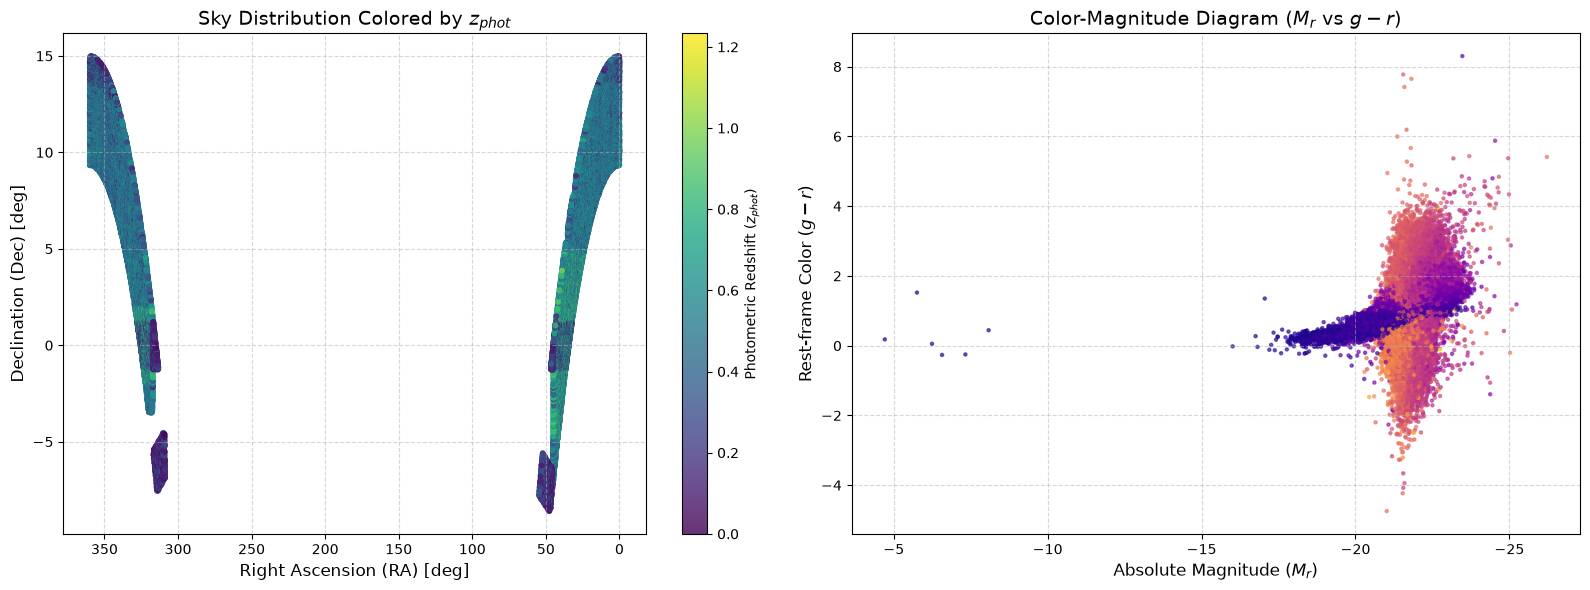

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# 1. 2D 空間散佈圖 (RA vs Dec colored by z_phot)
sc = axs[0].scatter(target_df['ra'], target_df['dec'], 
                    c=target_df['z_phot'], cmap='viridis', 
                    s=10, alpha=0.8)
axs[0].set_title('Sky Distribution Colored by $z_{phot}$', fontsize=14)
axs[0].set_xlabel('Right Ascension (RA) [deg]', fontsize=12)
axs[0].set_ylabel('Declination (Dec) [deg]', fontsize=12)
axs[0].invert_xaxis() # RA 通常向右遞減
axs[0].grid(True, linestyle='--', alpha=0.5)
cbar = plt.colorbar(sc, ax=axs[0])
cbar.set_label('Photometric Redshift ($z_{phot}$)')

# 2. Color-Magnitude Diagram: Absolute M_r vs (g-r) color
g_minus_r = target_df['dered_g'] - target_df['dered_r']
valid = np.isfinite(target_df['Absolute_Mag_r']) & np.isfinite(g_minus_r)

axs[1].scatter(target_df.loc[valid, 'Absolute_Mag_r'], 
               g_minus_r[valid], 
               c=target_df.loc[valid, 'z_phot'], cmap='plasma', 
               s=5, alpha=0.6)
axs[1].set_title('Color-Magnitude Diagram ($M_r$ vs $g-r$)', fontsize=14)
axs[1].set_xlabel('Absolute Magnitude ($M_r$)', fontsize=12)
axs[1].set_ylabel('Rest-frame Color ($g-r$)', fontsize=12)
axs[1].invert_xaxis() # 星等越小 (越亮) 在左邊
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

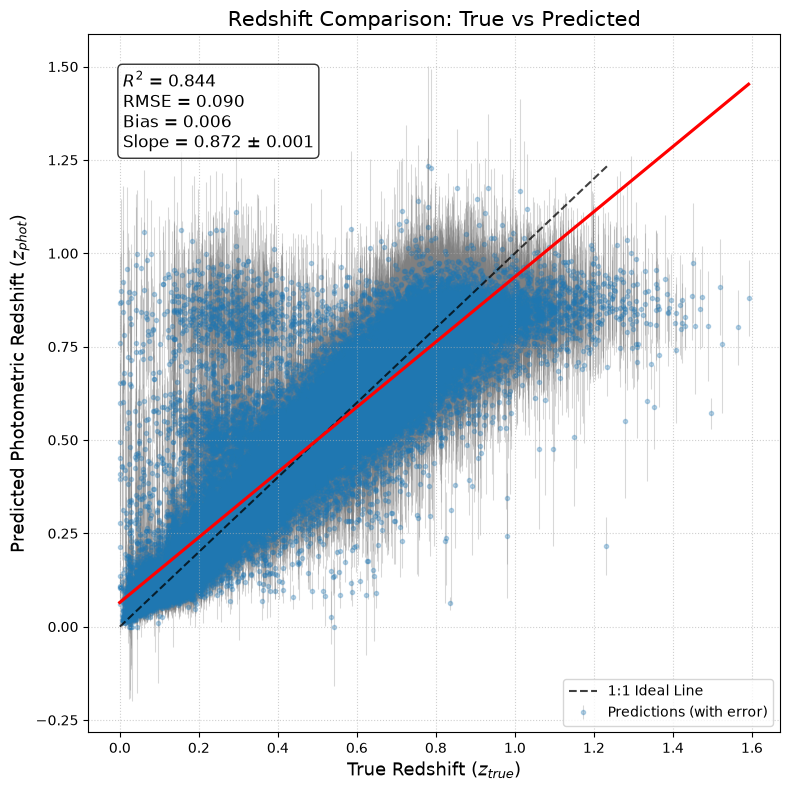

In [14]:
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

def plot_redshift_comparison(true_z, pred_z, pred_z_err=None):
    """
    繪製真實驗證紅移與推算測光紅移的比較圖，
    包含散佈圖、誤差線、1:1 理想對角線，以及線性迴歸與誤差區間。
    """
    # 過濾無效值 (NaN或無限大)
    valid_idx = np.isfinite(true_z) & np.isfinite(pred_z)
    x = true_z[valid_idx]
    y = pred_z[valid_idx]
    
    if pred_z_err is not None:
        y_err = pred_z_err[valid_idx]
    else:
        y_err = None
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # 1. 畫帶有誤差線的散佈圖 (Error bars)
    ax.errorbar(x, y, yerr=y_err, fmt='o', markersize=3, alpha=0.3, 
                ecolor='gray', elinewidth=0.8, capsize=0, zorder=1, label='Predictions (with error)')
    
    # 2. 畫 1:1 理想對角線 (Perfect Prediction)
    limits = [max(min(x), min(y)), min(max(x), max(y))]
    ax.plot(limits, limits, 'k--', alpha=0.75, zorder=2, label='1:1 Ideal Line')
    
    # 3. 執行線性迴歸與誤差區間繪製 (使用 seaborn.regplot 更為簡潔且美觀)
    # 預設會畫出 95% 信心區間 (Confidence Interval) 的半透明陰影帶
    sns.regplot(x=x, y=y, ax=ax, scatter=False, color='red', 
                line_kws={'label': 'Linear Regression (95% CI)', 'zorder': 3})
    
    # 4. 計算並顯示統計指標
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    rmse = np.sqrt(np.mean((y - x)**2))  # 均方根誤差
    bias = np.mean(y - x)                # 系統偏差
    
    # 將統計資訊標註在圖表左上角
    stats_text = (f"$R^2$ = {r_value**2:.3f}\n"
                  f"RMSE = {rmse:.3f}\n"
                  f"Bias = {bias:.3f}\n"
                  f"Slope = {slope:.3f} $\\pm$ {std_err:.3f}")
    
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props, zorder=4)
    
    ax.set_title('Redshift Comparison: True vs Predicted', fontsize=15)
    ax.set_xlabel('True Redshift ($z_{true}$)', fontsize=13)
    ax.set_ylabel('Predicted Photometric Redshift ($z_{phot}$)', fontsize=13)
    ax.legend(loc='lower right')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 📊 [使用範例] 利用訓練集的一部分來進行驗證
# ==========================================

# print("正在抽取 500 筆訓練集資料進行自我驗證比較...")

# 1. 抽出驗證集特徵與真實的 z_spec
val_features = target_features_scaled
val_z_true = target_df['spec_redshift'].values

# 2. 使用 LLR 函數對這些驗證樣本進行紅移預測
val_z_pred, val_z_err = calculate_photometric_redshift_llr(
    train_features_scaled, 
    train_df['spec_redshift'], 
    val_features, 
    k=100
)

# 3. 呼叫繪圖函數畫出對比與迴歸區間
plot_redshift_comparison(val_z_true, val_z_pred, pred_z_err=val_z_err)
